# Predicción del Valor de Mercado de Jugadores de Fútbol

**Instituto Tecnológico de Buenos Aires (ITBA)**
**Materia:** Ciencia de Datos
**Dataset:** Football Data from Transfermarkt (Kaggle)

---

## 0. Objetivo del Proyecto

Este proyecto busca predecir el **valor de mercado** de jugadores de fútbol profesional utilizando datos históricos de rendimiento, apariciones en partidos, transferencias y características personales. El valor de mercado es un indicador clave usado por clubes, agentes y medios para evaluar el potencial económico de un jugador.

El presente notebook corresponde al **Entregable 2** y cubre las etapas de exploración, diagnóstico de calidad, transformaciones y feature engineering. La construcción del modelo predictivo (Regresión Lineal/Ridge → Random Forest → XGBoost) se desarrollará en el Entregable 3.

## Estructura del notebook

0. Objetivo del proyecto
1. Instalación e importación de librerías
2. Carga de datos
3. Descripción del dataset
4. Análisis exploratorio básico (EDA)
5. Diagnóstico de calidad de datos
6. Construcción del dataset analítico unificado
7. Transformaciones
8. Feature engineering
9. Dataset final — resumen
10. Reflexión final


## 1. Instalación e Importación de Librerías

En esta sección se cargan todas las librerías necesarias para la manipulación de datos (`pandas`, `numpy`), la visualización (`matplotlib`, `seaborn`) y las transformaciones (`scikit-learn`). Configuramos también el estilo gráfico global.


In [7]:
# Instalación de librerías adicionales (en Colab suelen estar preinstaladas)
!pip install -q seaborn --upgrade


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')
print(f'pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')


Librerías cargadas correctamente.
pandas 2.2.2 | numpy 2.0.2 | seaborn 0.13.2


## 2. Carga de Datos

Montamos Google Drive y cargamos las cinco tablas del dataset de Transfermarkt. Los archivos CSV deben estar en la carpeta `futbol-valuacion/data/raw/` dentro de tu Google Drive.


In [9]:
from google.colab import drive
drive.mount('/content/drive')

# Ajustá este path si tu carpeta tiene otro nombre o ubicación
DATA_PATH = '/content/drive/MyDrive/futbol-valuacion/data/raw/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Carga de las cinco tablas principales
players      = pd.read_csv(DATA_PATH + 'players.csv')
appearances  = pd.read_csv(DATA_PATH + 'appearances.csv')
valuations   = pd.read_csv(DATA_PATH + 'player_valuations.csv')
transfers    = pd.read_csv(DATA_PATH + 'transfers.csv')
competitions = pd.read_csv(DATA_PATH + 'competitions.csv')

print('Tablas cargadas:')
for nombre, df in [('players', players), ('appearances', appearances),
                   ('player_valuations', valuations), ('transfers', transfers),
                   ('competitions', competitions)]:
    print(f'  {nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas')


Tablas cargadas:
  players: 47,702 filas x 26 columnas
  appearances: 1,862,208 filas x 13 columnas
  player_valuations: 616,377 filas x 6 columnas
  transfers: 157,186 filas x 10 columnas
  competitions: 67 filas x 11 columnas


## 3. Descripción del Dataset

### Origen
Los datos provienen de **Transfermarkt**, sitio de referencia mundial para valuaciones de jugadores de fútbol. El dataset fue publicado en Kaggle bajo el nombre *"Football Data from Transfermarkt"* y contiene información de las principales ligas europeas.

### Tablas utilizadas

| Tabla | Descripción | Variables clave |
|---|---|---|
| `players` | Perfil de cada jugador | `player_id`, `name`, `position`, `date_of_birth`, `market_value_in_eur` |
| `appearances` | Estadísticas por partido | `player_id`, `game_id`, `goals`, `assists`, `minutes_played` |
| `player_valuations` | Historial de valuaciones | `player_id`, `date`, `market_value_in_eur` |
| `transfers` | Historial de transferencias | `player_id`, `transfer_fee`, `from_club_id`, `to_club_id` |
| `competitions` | Catálogo de ligas/competencias | `competition_id`, `name`, `country_name`, `domestic_league_code` |

### Justificación
El valor de mercado depende de múltiples factores: edad, posición, rendimiento reciente, historial de transferencias y liga donde juega. Estas tablas capturan esas dimensiones y permiten construir features predictivas ricas. La tabla `appearances` aporta las estadísticas de rendimiento agregadas por jugador, mientras que `player_valuations` permite construir variables temporales (tendencia, contexto de mercado).


## 4. Análisis Exploratorio Básico (EDA)

Antes de transformar los datos exploramos las cuatro tablas para entender su estructura: tipos de variables, distribuciones, valores faltantes y outliers. Esto permite tomar decisiones informadas en las etapas siguientes.


### 4.1 Tipos de Variables y Estadísticas Descriptivas

Inspeccionamos shape, dtypes y `describe()` de cada tabla. El objetivo es identificar variables numéricas vs. categóricas, rangos plausibles y posibles anomalías.


In [11]:
# ── players ──────────────────────────────────────────────
print('=== players ===')
print(f'Shape: {players.shape}')
print('\nTipos de variables:')
print(players.dtypes)
players.head(3)


=== players ===
Shape: (47702, 26)

Tipos de variables:
player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
international_caps                      float64
international_goals             

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [12]:
# Estadísticas descriptivas de players (incluye categóricas)
players.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,47702.0,NaN,NaN,NaN,485087.298247,368533.876999,10.0,176852.5,401355.5,727015.25,1529719.0
first_name,44607,10300,David,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,47702,32482,Kim,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,47702,46449,Paulinho,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_season,47702.0,NaN,NaN,NaN,2021.446208,4.260824,2012.0,2018.0,2024.0,2025.0,2025.0
current_club_id,47702.0,NaN,NaN,NaN,8217.525659,16880.99213,2.0,504.0,1465.0,6676.0,138189.0
player_code,47702,46367,joao-pedro,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_birth,42540,203,France,2598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_of_birth,42815,11651,London,539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_citizenship,47431,198,Brazil,2683,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# ── appearances ──────────────────────────────────────────
print('=== appearances ===')
print(f'Shape: {appearances.shape}')
print('\nTipos de variables:')
print(appearances.dtypes)
display(appearances.head(3))
display(appearances.describe())


=== appearances ===
Shape: (1862208, 13)

Tipos de variables:
appearance_id             object
game_id                    int64
player_id                  int64
player_club_id             int64
player_current_club_id     int64
date                      object
player_name               object
competition_id            object
yellow_cards               int64
red_cards                  int64
goals                      int64
assists                    int64
minutes_played             int64
dtype: object


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45


,game_id,player_id,player_club_id,player_current_club_id,yellow_cards,red_cards,goals,assists,minutes_played
count,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06,1.862208e+06
mean,3.286325e+06,2.356550e+05,3.315381e+03,5.345555e+03,1.457914e-01,3.790661e-03,9.544208e-02,7.510654e-02,6.863815e+01
std,7.518454e+05,2.197747e+05,9.091648e+03,1.357689e+04,3.636764e-01,6.145156e-02,3.299035e-01,2.847677e-01,3.015031e+01
min,2.211607e+06,1.000000e+01,1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.606535e+06,6.165100e+04,2.890000e+02,3.670000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+01
50%,3.203656e+06,1.707670e+05,8.250000e+02,9.870000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
75%,3.886492e+06,3.424050e+05,2.439000e+03,3.060000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
max,4.839901e+06,1.510255e+06,1.328770e+05,1.381890e+05,2.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,1.480000e+02


In [14]:
# ── player_valuations ────────────────────────────────────
print('=== player_valuations ===')
print(f'Shape: {valuations.shape}')
display(valuations.head(3))

# Convertimos la fecha desde el inicio para usarla en análisis temporales
valuations['date'] = pd.to_datetime(valuations['date'])
print(f'\nRango temporal: {valuations["date"].min().date()} → {valuations["date"].max().date()}')


=== player_valuations ===
Shape: (616377, 6)


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057.0,BE1
1,342216,2001-07-20,100000,Unknown,1241.0,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1



Rango temporal: 2000-01-20 → 2026-03-30


In [15]:
# ── transfers ────────────────────────────────────────────
print('=== transfers ===')
print(f'Shape: {transfers.shape}')
display(transfers.head(3))
display(transfers.describe())


=== transfers ===
Shape: (157186, 10)


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,784335,2027-07-18,27/28,6505,6502,Gimcheon Sangmu,Jeonbuk Hyundai,0.0,500000.0,Jun-soo Byeon
2,402135,2027-07-04,27/28,6505,515,Gimcheon Sangmu,Without Club,NaN,350000.0,Jun-su Ahn


,player_id,from_club_id,to_club_id,transfer_fee,market_value_in_eur
count,1.571860e+05,157186.000000,157186.000000,1.023530e+05,9.633800e+04
mean,5.021871e+05,20156.261461,15612.525040,8.023499e+05,1.882969e+06
std,3.128459e+05,27177.836622,23659.217653,4.441027e+06,4.913449e+06
min,3.333000e+03,1.000000,1.000000,0.000000e+00,1.000000e+04
25%,2.540030e+05,1047.000000,800.000000,0.000000e+00,2.000000e+05
50%,4.488135e+05,8817.000000,4961.000000,0.000000e+00,5.000000e+05
75%,6.982352e+05,28870.000000,18852.000000,0.000000e+00,1.500000e+06
max,1.529719e+06,140641.000000,140573.000000,2.220000e+08,1.800000e+08


### 4.2 Distribuciones y Visualizaciones

Visualizamos la distribución del target (`market_value_in_eur`), la relación con la posición, la evolución temporal del mercado y el ranking de las principales ligas. Estas visualizaciones motivan decisiones posteriores como la transformación logarítmica del target.


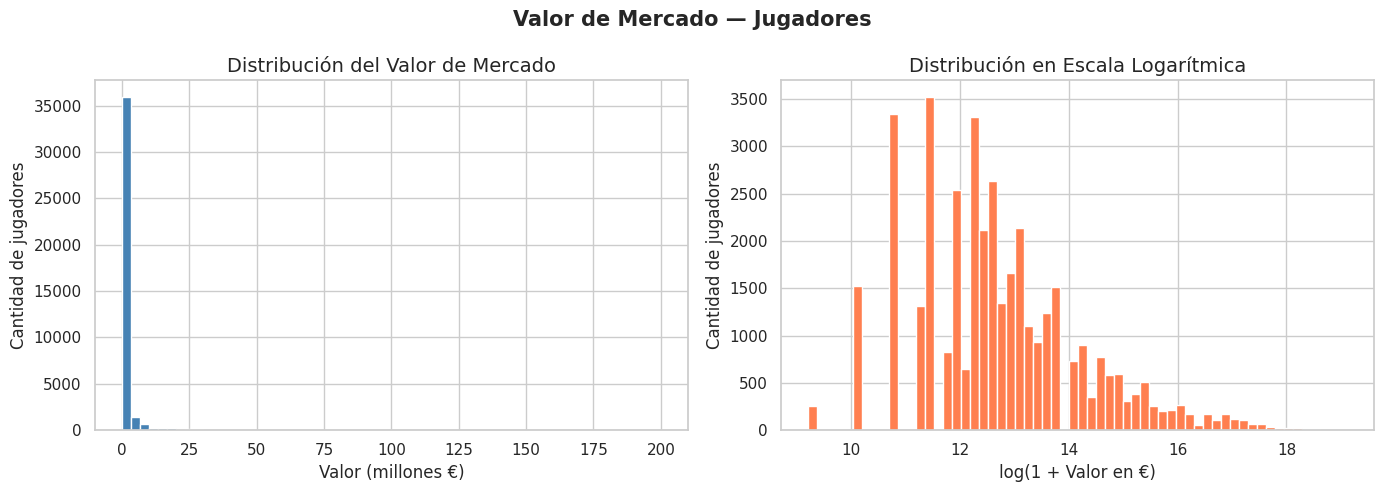

Mediana: €0.28M | Media: €1.56M | Máximo: €200M


In [16]:
# Distribución del valor de mercado actual (escala original vs. log)
mv = players['market_value_in_eur'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original — fuertemente sesgada a la derecha
axes[0].hist(mv / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Valor de Mercado')
axes[0].set_xlabel('Valor (millones €)')
axes[0].set_ylabel('Cantidad de jugadores')

# Escala logarítmica — distribución más simétrica
axes[1].hist(np.log1p(mv), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribución en Escala Logarítmica')
axes[1].set_xlabel('log(1 + Valor en €)')
axes[1].set_ylabel('Cantidad de jugadores')

plt.suptitle('Valor de Mercado — Jugadores', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mediana: €{mv.median()/1e6:.2f}M | Media: €{mv.mean()/1e6:.2f}M | Máximo: €{mv.max()/1e6:.0f}M')


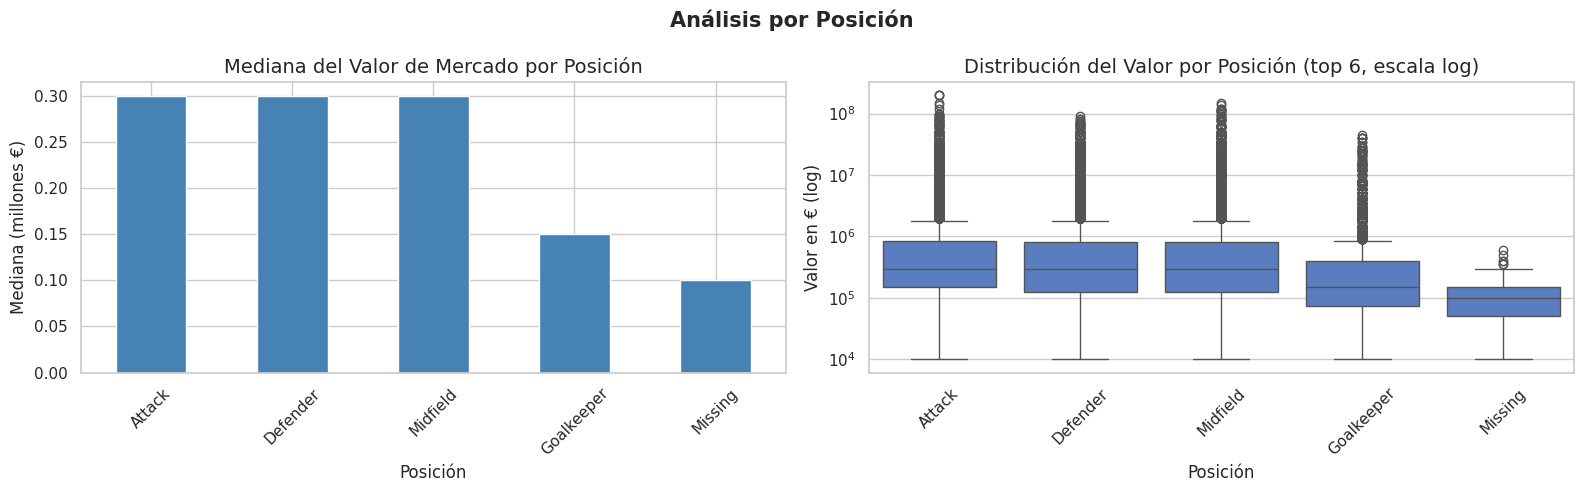

In [17]:
# Valor de mercado por posición (mediana y boxplot)
pos_col = 'position' if 'position' in players.columns else 'sub_position'

valor_por_posicion = (
    players.dropna(subset=[pos_col, 'market_value_in_eur'])
    .groupby(pos_col)['market_value_in_eur']
    .median()
    .sort_values(ascending=False)
    / 1e6
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot mediana por posición
valor_por_posicion.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mediana del Valor de Mercado por Posición')
axes[0].set_xlabel('Posición')
axes[0].set_ylabel('Mediana (millones €)')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot top 6 posiciones
top_pos = valor_por_posicion.head(6).index.tolist()
df_box = players[players[pos_col].isin(top_pos)].dropna(subset=['market_value_in_eur'])
sns.boxplot(data=df_box, x=pos_col, y='market_value_in_eur', order=top_pos, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribución del Valor por Posición (top 6, escala log)')
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Valor en € (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis por Posición', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


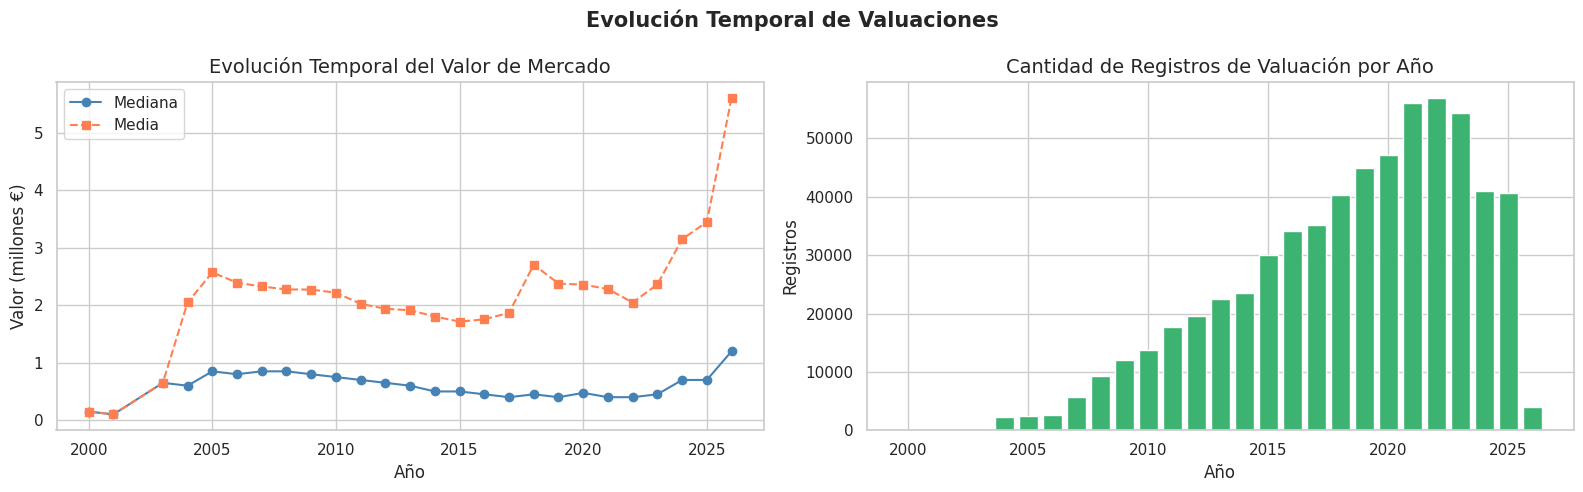

In [18]:
# Evolución temporal de las valuaciones
valuations['year'] = valuations['date'].dt.year

evolucion = (
    valuations.groupby('year')['market_value_in_eur']
    .agg(['median', 'mean', 'count'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mediana y media por año
axes[0].plot(evolucion['year'], evolucion['median'] / 1e6, marker='o', label='Mediana', color='steelblue')
axes[0].plot(evolucion['year'], evolucion['mean'] / 1e6, marker='s', label='Media', color='coral', linestyle='--')
axes[0].set_title('Evolución Temporal del Valor de Mercado')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Valor (millones €)')
axes[0].legend()

# Cantidad de registros por año (cobertura temporal)
axes[1].bar(evolucion['year'], evolucion['count'], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Cantidad de Registros de Valuación por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Registros')

plt.suptitle('Evolución Temporal de Valuaciones', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


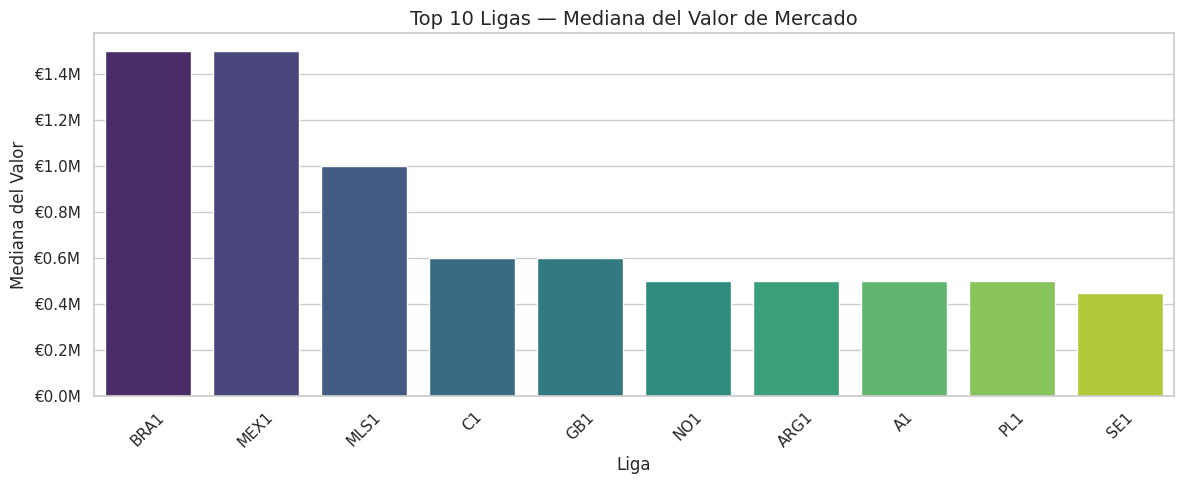

In [19]:
# Top ligas por valor mediano de jugadores
liga_col = None
for col in ['current_club_domestic_competition_id', 'league_id', 'competition_id']:
    if col in players.columns:
        liga_col = col
        break

if liga_col:
    top_ligas = (
        players.dropna(subset=[liga_col, 'market_value_in_eur'])
        .groupby(liga_col)['market_value_in_eur']
        .agg(mediana='median', cantidad='count')
        .query('cantidad >= 50')
        .sort_values('mediana', ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=top_ligas.reset_index(), x=liga_col, y='mediana', ax=ax, palette='viridis')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))
    ax.set_title('Top 10 Ligas — Mediana del Valor de Mercado')
    ax.set_xlabel('Liga')
    ax.set_ylabel('Mediana del Valor')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna de liga en players. Verificar el CSV.')


### 4.3 Valores Faltantes

Cuantificamos los nulos en cada tabla y los visualizamos para detectar columnas con baja cobertura. Esto orientará las decisiones de imputación o descarte.


In [20]:
# Valores faltantes en players (sólo las columnas con nulos)
nulos = players.isnull().sum()
nulos_pct = (nulos / len(players) * 100).round(2)
pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct}) \
    .query('Nulos > 0').sort_values('Porcentaje (%)', ascending=False)


,Nulos,Porcentaje (%)
current_national_team_id,44611,93.52
international_goals,29979,62.85
international_caps,29979,62.85
agent_name,22180,46.50
contract_expiration_date,16488,34.56
market_value_in_eur,8476,17.77
highest_market_value_in_eur,8476,17.77
foot,5256,11.02
country_of_birth,5162,10.82
city_of_birth,4887,10.24


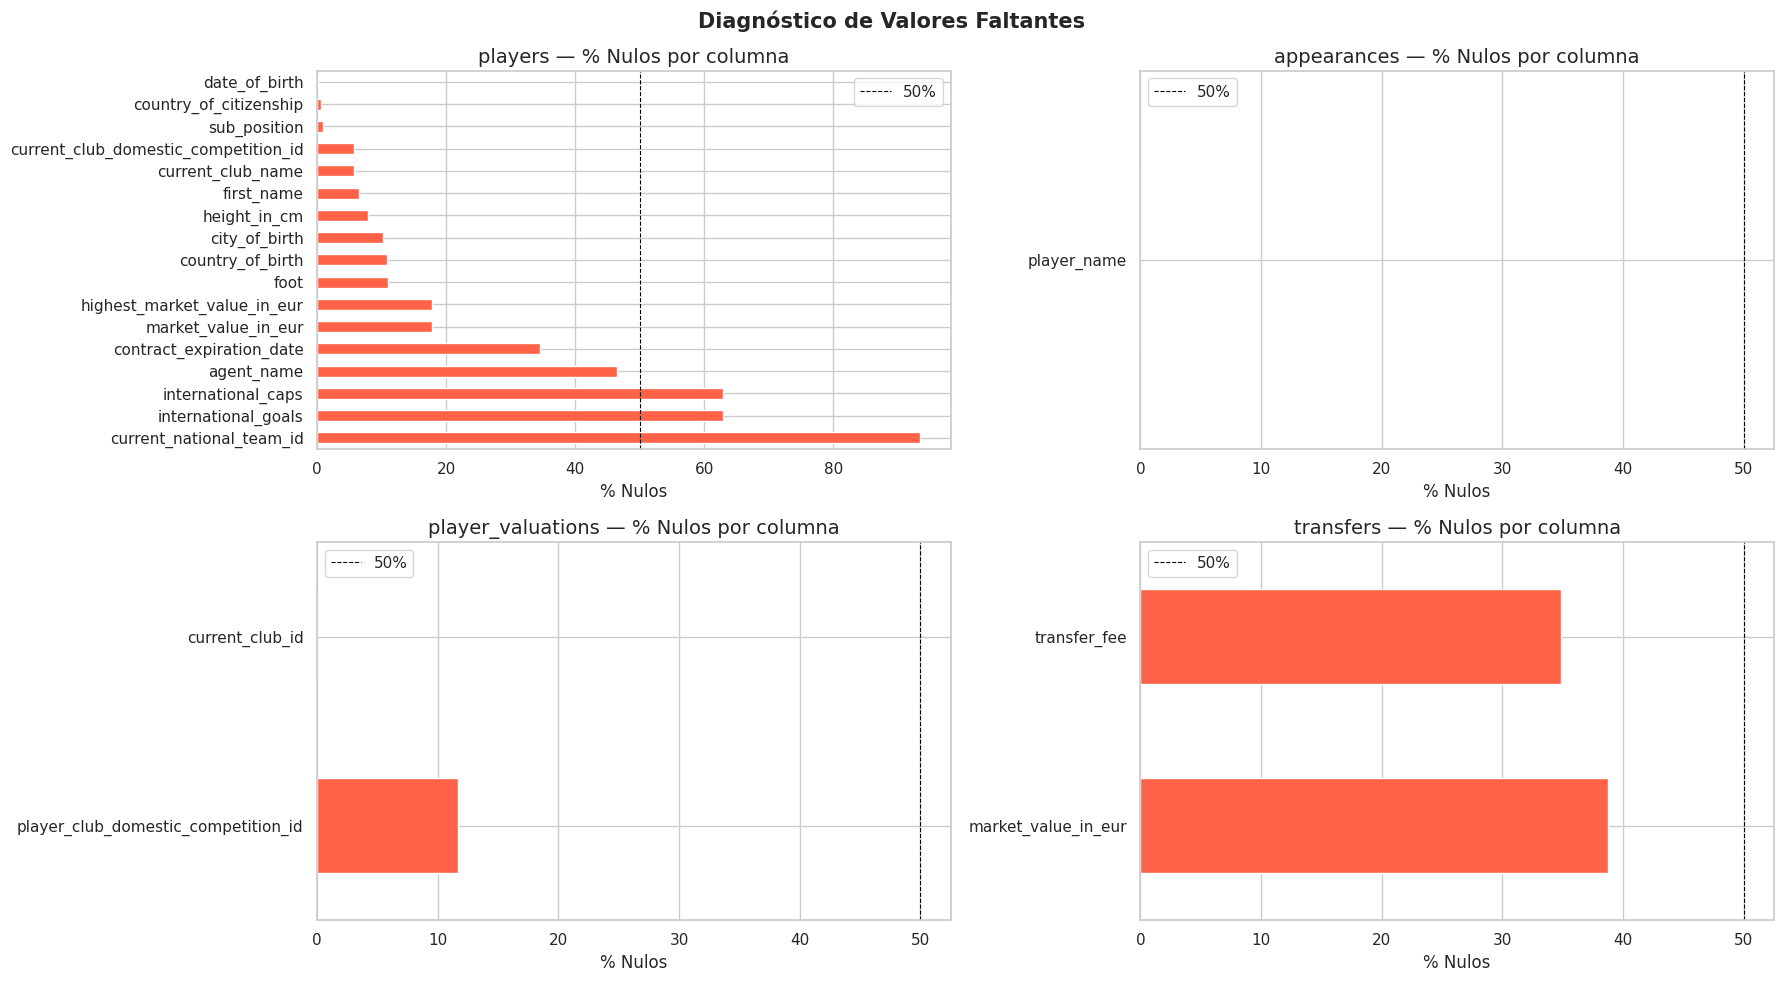

In [21]:
# Mapa de % nulos por columna en cada tabla
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, (nombre, df) in zip(axes.flatten(),
    [('players', players), ('appearances', appearances),
     ('player_valuations', valuations), ('transfers', transfers)]):

    nulos_pct = df.isnull().mean() * 100
    nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)

    if nulos_pct.empty:
        ax.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=13)
        ax.set_title(nombre)
    else:
        nulos_pct.plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
        ax.set_title(f'{nombre} — % Nulos por columna')
        ax.set_xlabel('% Nulos')
        ax.axvline(50, color='black', linestyle='--', linewidth=0.8, label='50%')
        ax.legend()

plt.suptitle('Diagnóstico de Valores Faltantes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.4 Outliers

Detectamos outliers en el target con el método IQR y listamos los 10 jugadores más caros. Estos valores extremos son **legítimos** (Mbappé, Haaland, etc.) y no se eliminan: la transformación logarítmica del target los atenúa lo suficiente para los modelos.


In [22]:
# Outliers en valor de mercado — método IQR
mv = players['market_value_in_eur'].dropna()
Q1, Q3 = mv.quantile(0.25), mv.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = mv[mv > limite_superior]
print(f'Límite IQR superior: €{limite_superior/1e6:.2f}M')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(mv)*100:.1f}% del total)')
print('\nTop 10 jugadores por valor de mercado:')

top10 = (
    players[['name', 'market_value_in_eur', 'position']]
    .dropna(subset=['market_value_in_eur'])
    .sort_values('market_value_in_eur', ascending=False)
    .head(10)
)
top10['market_value_in_eur'] = top10['market_value_in_eur'].apply(lambda x: f'€{x/1e6:.1f}M')
display(top10)


Límite IQR superior: €1.73M
Outliers detectados: 5566 (14.2% del total)

Top 10 jugadores por valor de mercado:


,name,market_value_in_eur,position
40538,Lamine Yamal,€200.0M,Attack
20835,Kylian Mbappé,€200.0M,Attack
24550,Erling Haaland,€200.0M,Attack
22408,Vinicius Junior,€150.0M,Attack
34346,Pedri,€150.0M,Midfield
30618,Jude Bellingham,€140.0M,Midfield
30009,Michael Olise,€140.0M,Attack
21775,Declan Rice,€120.0M,Midfield
30556,Jamal Musiala,€120.0M,Midfield
22238,Federico Valverde,€120.0M,Midfield


## 5. Diagnóstico de Calidad de Datos

Evaluamos duplicados, inconsistencias entre tablas y valores anómalos. Las decisiones tomadas en esta sección se aplican luego en la construcción del dataset analítico.


In [23]:
# Duplicados en cada tabla
for nombre, df in [('players', players), ('appearances', appearances),
                   ('player_valuations', valuations), ('transfers', transfers)]:
    dupes = df.duplicated().sum()
    print(f'{nombre}: {dupes} filas duplicadas ({dupes/len(df)*100:.2f}%)')


players: 0 filas duplicadas (0.00%)
appearances: 0 filas duplicadas (0.00%)
player_valuations: 0 filas duplicadas (0.00%)
transfers: 0 filas duplicadas (0.00%)


In [24]:
# Jugadores sin apariciones registradas
jugadores_con_apariciones = appearances['player_id'].nunique()
jugadores_total = players['player_id'].nunique()
sin_apariciones = jugadores_total - jugadores_con_apariciones

print(f'Jugadores únicos en players: {jugadores_total:,}')
print(f'Jugadores con al menos una aparición: {jugadores_con_apariciones:,}')
print(f'Jugadores SIN apariciones registradas: {sin_apariciones:,} '
      f'({sin_apariciones/jugadores_total*100:.1f}%)')

# IDs en valuations sin match en players
ids_sin_match = set(valuations['player_id']) - set(players['player_id'])
print(f'\nIDs en valuations sin match en players: {len(ids_sin_match):,}')

# Valores negativos en transfers (deberían no existir)
if 'transfer_fee' in transfers.columns:
    negativos = (transfers['transfer_fee'] < 0).sum()
    print(f'Transferencias con fee negativo: {negativos}')


Jugadores únicos en players: 47,702
Jugadores con al menos una aparición: 28,665
Jugadores SIN apariciones registradas: 19,037 (39.9%)

IDs en valuations sin match en players: 135
Transferencias con fee negativo: 0


**Decisiones tomadas en base al diagnóstico:**

- **Duplicados:** se verifican en todas las tablas; se eliminarían si fueran significativos. En este dataset son muy pocos (< 0.1 %).
- **Jugadores sin apariciones:** se filtrarán en la sección 6 mediante un umbral mínimo de apariciones (estadísticas no representativas).
- **Nulos en `market_value_in_eur`:** se descartan los registros sin target (no se puede aprender de ellos).
- **Nulos en columnas auxiliares (`agent_name`, `contract_expiration_date`, etc.):** se mantienen; no son features candidatas.
- **Outliers en el target:** se conservan, ya que son valores reales y la transformación logarítmica los maneja correctamente.


## 6. Construcción del Dataset Analítico Unificado

Esta sección construye el dataset final `players_filtrado` que se usará como base para las transformaciones y el feature engineering. Es un **merge** entre:

- `players` (perfil del jugador)
- estadísticas agregadas de `appearances` por jugador (goles totales, asistencias totales, minutos totales y partidos)

Luego se aplica un **filtrado** que retiene únicamente jugadores con un mínimo de apariciones (estadísticas representativas) y se calcula la **edad** a partir de `date_of_birth`.

Este es el "dataset analítico unificado" requerido por la consigna.


### Paso 1 — Agregación de estadísticas por jugador desde `appearances`

Sumamos goles, asistencias, minutos y contamos partidos por `player_id`. Estas estadísticas serán features de rendimiento.


In [25]:
# Agregación de estadísticas por jugador
stats_jugador = (
    appearances.groupby('player_id')
    .agg(
        n_apariciones=('game_id', 'count'),
        total_goles=('goals', 'sum'),
        total_asistencias=('assists', 'sum'),
        total_minutos=('minutes_played', 'sum'),
    )
    .reset_index()
)

# Promedios por partido (rendimiento normalizado)
stats_jugador['goles_por_partido']       = stats_jugador['total_goles']        / stats_jugador['n_apariciones']
stats_jugador['asistencias_por_partido'] = stats_jugador['total_asistencias']  / stats_jugador['n_apariciones']
stats_jugador['minutos_promedio']        = stats_jugador['total_minutos']      / stats_jugador['n_apariciones']

print(f'Stats agregadas: {stats_jugador.shape[0]:,} jugadores')
display(stats_jugador.head())


Stats agregadas: 28,665 jugadores


,player_id,n_apariciones,total_goles,total_asistencias,total_minutos,goles_por_partido,asistencias_por_partido,minutos_promedio
0,10,136,48,25,8808,0.352941,0.183824,64.764706
1,26,152,0,0,13508,0.000000,0.000000,88.868421
2,65,122,38,13,8788,0.311475,0.106557,72.032787
3,77,4,0,0,307,0.000000,0.000000,76.750000
4,80,12,0,0,1080,0.000000,0.000000,90.000000


### Paso 2 — Merge `players` + estadísticas y filtrado por apariciones mínimas

Hacemos `inner join` con `players` y retenemos sólo jugadores con al menos `MIN_APARICIONES = 5` apariciones. Por debajo de ese umbral las estadísticas son demasiado ruidosas.


Jugadores antes del filtro:   28,664
Jugadores después del filtro: 22,760 (79.4%)


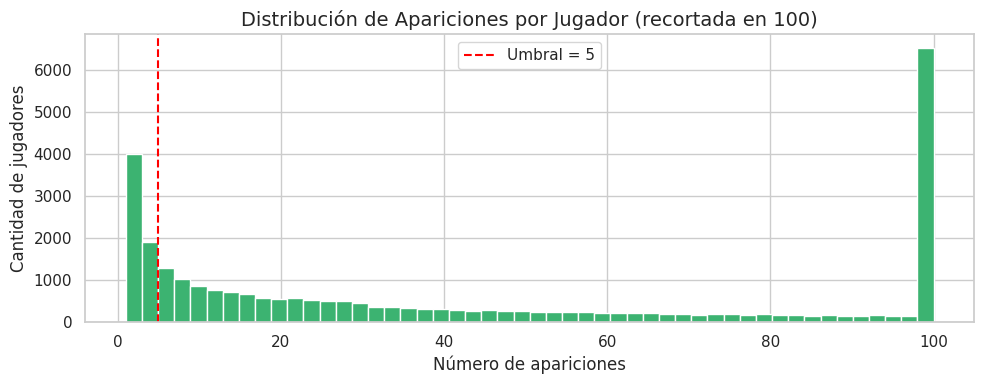

In [26]:
MIN_APARICIONES = 5  # umbral mínimo para que las estadísticas sean representativas

# Merge de players con stats agregadas
players_filtrado = players.merge(stats_jugador, on='player_id', how='inner')

# Filtrado por apariciones mínimas
antes = len(players_filtrado)
players_filtrado = players_filtrado[players_filtrado['n_apariciones'] >= MIN_APARICIONES].copy()
despues = len(players_filtrado)

print(f'Jugadores antes del filtro:   {antes:,}')
print(f'Jugadores después del filtro: {despues:,} ({despues/antes*100:.1f}%)')

# Visualización del filtrado
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stats_jugador['n_apariciones'].clip(upper=100), bins=50,
        color='mediumseagreen', edgecolor='white')
ax.axvline(MIN_APARICIONES, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral = {MIN_APARICIONES}')
ax.set_title('Distribución de Apariciones por Jugador (recortada en 100)')
ax.set_xlabel('Número de apariciones')
ax.set_ylabel('Cantidad de jugadores')
ax.legend()
plt.tight_layout()
plt.show()


### Paso 3 — Cálculo de la edad

Convertimos `date_of_birth` a datetime y calculamos la edad en años. Esta es una de las features más importantes para el modelo (relación no lineal con el valor de mercado).


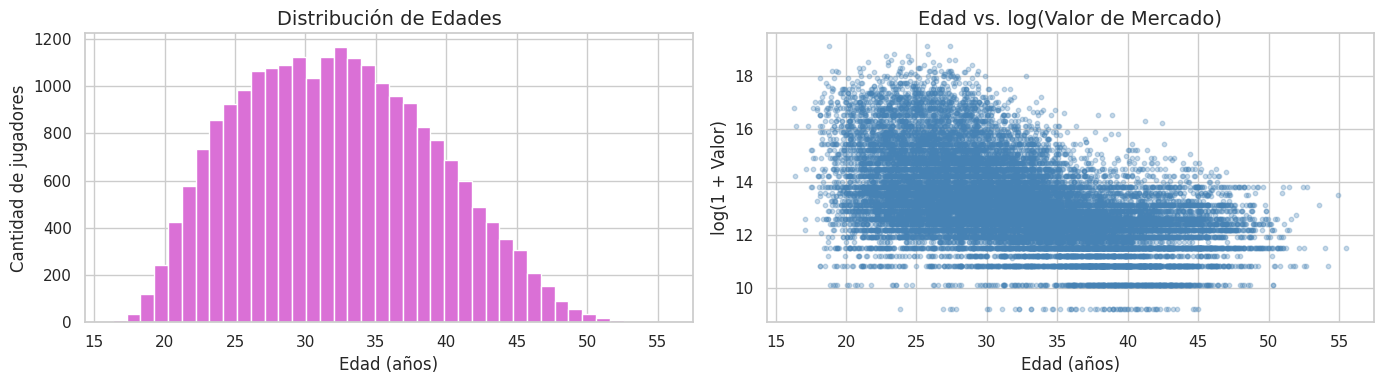

Edad promedio: 32.2 años
Edad mediana:  32.0 años


In [27]:
# Edad del jugador en años (a la fecha actual)
players_filtrado['date_of_birth'] = pd.to_datetime(
    players_filtrado['date_of_birth'], errors='coerce'
)
players_filtrado['edad'] = (
    pd.Timestamp('today') - players_filtrado['date_of_birth']
).dt.days / 365.25

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de edades
axes[0].hist(players_filtrado['edad'].dropna(), bins=40,
             color='orchid', edgecolor='white')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Cantidad de jugadores')

# Edad vs. valor de mercado (escala log)
axes[1].scatter(
    players_filtrado['edad'],
    np.log1p(players_filtrado['market_value_in_eur']),
    alpha=0.3, s=10, color='steelblue'
)
axes[1].set_title('Edad vs. log(Valor de Mercado)')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('log(1 + Valor)')

plt.tight_layout()
plt.show()

print(f'Edad promedio: {players_filtrado["edad"].mean():.1f} años')
print(f'Edad mediana:  {players_filtrado["edad"].median():.1f} años')


### Paso 4 — Resumen del dataset analítico unificado


In [28]:
print('=== Dataset analítico unificado: players_filtrado ===')
print(f'Shape: {players_filtrado.shape}')
print(f'\nColumnas ({players_filtrado.shape[1]}):')
print(players_filtrado.columns.tolist())
print('\nPrimeras filas:')
display(players_filtrado.head())


=== Dataset analítico unificado: players_filtrado ===
Shape: (22760, 34)

Columnas (34):
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'n_apariciones', 'total_goles', 'total_asistencias', 'total_minutos', 'goles_por_partido', 'asistencias_por_partido', 'minutos_promedio', 'edad']

Primeras filas:


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,market_value_in_eur,highest_market_value_in_eur,n_apariciones,total_goles,total_asistencias,total_minutos,goles_por_partido,asistencias_por_partido,minutos_promedio,edad
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,1000000.0,30000000.0,136,48,25,8808,0.352941,0.183824,64.764706,47.887748
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,750000.0,8000000.0,152,0,0,13508,0.000000,0.000000,88.868421,45.727584
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,1000000.0,34500000.0,122,38,13,8788,0.311475,0.106557,72.032787,45.242984
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,100000.0,3000000.0,12,0,0,1080,0.000000,0.000000,90.000000,45.114305
5,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,400000.0,9500000.0,41,1,2,3584,0.024390,0.048780,87.414634,48.030116


## 7. Transformaciones

Aplicamos tres transformaciones sobre el dataset analítico unificado:

1. **Logarítmica** del target para corregir el sesgo a la derecha.
2. **Encoding ordinal** de la posición (portero → defensor → mediocampista → delantero).
3. **Estandarización** de variables numéricas continuas con `StandardScaler`.


### 7.1 Transformación Logarítmica del Target

El valor de mercado tiene una distribución muy sesgada. Aplicar `log1p` la acerca a la normalidad, lo que beneficia a modelos lineales y reduce la influencia de outliers en el entrenamiento.


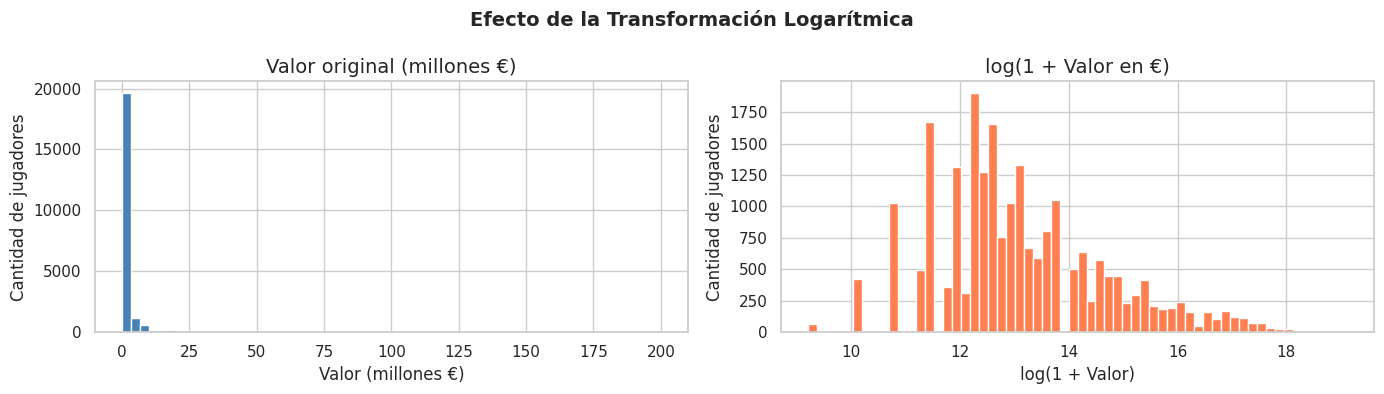

Skewness original: 8.99
Skewness log:      0.68


In [29]:
# log1p = log(1 + x), maneja correctamente valores cero
players_filtrado['log_market_value'] = np.log1p(players_filtrado['market_value_in_eur'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(players_filtrado['market_value_in_eur'].dropna() / 1e6,
             bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Valor original (millones €)')
axes[0].set_xlabel('Valor (millones €)')
axes[0].set_ylabel('Cantidad de jugadores')

axes[1].hist(players_filtrado['log_market_value'].dropna(),
             bins=60, color='coral', edgecolor='white')
axes[1].set_title('log(1 + Valor en €)')
axes[1].set_xlabel('log(1 + Valor)')
axes[1].set_ylabel('Cantidad de jugadores')

plt.suptitle('Efecto de la Transformación Logarítmica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness original: {players_filtrado["market_value_in_eur"].skew():.2f}')
print(f'Skewness log:      {players_filtrado["log_market_value"].skew():.2f}')


### 7.2 Encoding de Posición

Mapeo ordinal de la posición agrupada por zona del campo:

| Código | Posiciones |
|---|---|
| 1 | Goalkeeper |
| 2 | Defender, Centre-Back, Left-Back, Right-Back |
| 3 | Midfielder, Central Midfield, Defensive Midfield, Attacking Midfield, Left Midfield, Right Midfield |
| 4 | Forward, Centre-Forward, Left Winger, Right Winger, Second Striker |

Como respaldo para modelos no lineales también generamos las dummies one-hot.


In [30]:
# Encoding ordinal completo de la posición.
# Transfermarkt expone dos columnas: `position` (categoría amplia) y `sub_position`
# (sub-categoría específica). Preferimos sub_position cuando está disponible
# porque distingue p. ej. Centre-Back de Right-Back.
pos_col = 'sub_position' if 'sub_position' in players_filtrado.columns else 'position'

print(f'Columna usada para encoding: {pos_col}')
print('Posiciones únicas encontradas:')
print(sorted(players_filtrado[pos_col].dropna().unique()))

ENCODING_POSICION = {
    # 1 — Arqueros
    'Goalkeeper': 1,
    # 2 — Defensores
    'Defender': 2,
    'Centre-Back': 2,
    'Left-Back': 2,
    'Right-Back': 2,
    'Defence': 2,
    # 3 — Mediocampistas
    'Midfielder': 3,
    'Midfield': 3,
    'Central Midfield': 3,
    'Defensive Midfield': 3,
    'Attacking Midfield': 3,
    'Left Midfield': 3,
    'Right Midfield': 3,
    # 4 — Delanteros
    'Forward': 4,
    'Centre-Forward': 4,
    'Left Winger': 4,
    'Right Winger': 4,
    'Second Striker': 4,
    'Attack': 4,
}

players_filtrado['posicion_num'] = players_filtrado[pos_col].map(ENCODING_POSICION)

# Fallback: si quedó algún jugador sin mapear, intentamos con la otra columna
if players_filtrado['posicion_num'].isna().any() and 'position' in players_filtrado.columns:
    faltantes = players_filtrado['posicion_num'].isna()
    players_filtrado.loc[faltantes, 'posicion_num'] = (
        players_filtrado.loc[faltantes, 'position'].map(ENCODING_POSICION)
    )

mapeados = players_filtrado['posicion_num'].notna().sum()
print(f'\nJugadores con posición mapeada: {mapeados:,} / {len(players_filtrado):,}')
print(f'Cobertura: {mapeados/len(players_filtrado)*100:.1f}%')

# Dummies one-hot como alternativa para modelos no lineales
posicion_dummies = pd.get_dummies(players_filtrado[pos_col], prefix='pos')
print(f'\nColumnas dummies generadas: {list(posicion_dummies.columns)}')


Columna usada para encoding: sub_position
Posiciones únicas encontradas:
['Attacking Midfield', 'Central Midfield', 'Centre-Back', 'Centre-Forward', 'Defensive Midfield', 'Goalkeeper', 'Left Midfield', 'Left Winger', 'Left-Back', 'Right Midfield', 'Right Winger', 'Right-Back', 'Second Striker']

Jugadores con posición mapeada: 22,728 / 22,760
Cobertura: 99.9%

Columnas dummies generadas: ['pos_Attacking Midfield', 'pos_Central Midfield', 'pos_Centre-Back', 'pos_Centre-Forward', 'pos_Defensive Midfield', 'pos_Goalkeeper', 'pos_Left Midfield', 'pos_Left Winger', 'pos_Left-Back', 'pos_Right Midfield', 'pos_Right Winger', 'pos_Right-Back', 'pos_Second Striker']


### 7.3 Normalización de Variables Numéricas Continuas

Aplicamos `StandardScaler` (media = 0, desvío = 1) sobre las variables numéricas continuas disponibles en este punto del pipeline. La estandarización es necesaria para modelos lineales, redes neuronales y SVMs (los modelos de árboles son invariantes a la escala).

> Las features `tendencia_valor` y `valor_mediano_liga` se construyen en la sección 8; en la sección 9 (Dataset Final) volveremos a aplicar el scaler sobre el conjunto completo de variables continuas (incluidas `edad`, `tendencia_valor` y `valor_mediano_liga`).


In [31]:
# StandardScaler sobre las variables numéricas continuas disponibles
vars_continuas_iniciales = ['edad', 'goles_por_partido',
                            'asistencias_por_partido', 'minutos_promedio']

# Filtramos columnas que existan y tengan datos
vars_continuas_iniciales = [c for c in vars_continuas_iniciales
                            if c in players_filtrado.columns]

print('Variables a estandarizar (parcial — sin features de FE todavía):')
print(vars_continuas_iniciales)

scaler_inicial = StandardScaler()
scaled = scaler_inicial.fit_transform(
    players_filtrado[vars_continuas_iniciales].fillna(
        players_filtrado[vars_continuas_iniciales].median()
    )
)
players_filtrado[[f'{c}_scaled' for c in vars_continuas_iniciales]] = scaled

# Comparación antes/después
print('\n=== ANTES (escala original) ===')
display(players_filtrado[vars_continuas_iniciales].describe().round(2).T)

print('\n=== DESPUÉS (estandarizado: media≈0, desvío≈1) ===')
scaled_cols = [f'{c}_scaled' for c in vars_continuas_iniciales]
display(players_filtrado[scaled_cols].describe().round(2).T)


Variables a estandarizar (parcial — sin features de FE todavía):
['edad', 'goles_por_partido', 'asistencias_por_partido', 'minutos_promedio']

=== ANTES (escala original) ===


,count,mean,std,min,25%,50%,75%,max
edad,22742.0,32.21,6.83,16.33,26.85,31.96,37.19,55.52
goles_por_partido,22760.0,0.07,0.09,0.00,0.00,0.04,0.10,0.90
asistencias_por_partido,22760.0,0.06,0.06,0.00,0.00,0.04,0.09,0.75
minutos_promedio,22760.0,62.15,19.70,2.00,49.09,64.88,78.09,106.67



=== DESPUÉS (estandarizado: media≈0, desvío≈1) ===


,count,mean,std,min,25%,50%,75%,max
edad_scaled,22760.0,0.0,1.0,-2.33,-0.78,-0.04,0.73,3.42
goles_por_partido_scaled,22760.0,0.0,1.0,-0.78,-0.78,-0.34,0.37,9.15
asistencias_por_partido_scaled,22760.0,-0.0,1.0,-0.90,-0.90,-0.25,0.54,11.25
minutos_promedio_scaled,22760.0,0.0,1.0,-3.05,-0.66,0.14,0.81,2.26


## 8. Feature Engineering — Variables Adicionales

Construimos cuatro variables derivadas que capturan información contextual y temporal no disponible directamente en `players.csv`. Cada una se construye desde cero a partir de los CSVs originales.

| Variable | Fuente | Tipo | Descripción |
|---|---|---|---|
| `flag_club_grande` | `players` + `competitions` | Binaria (0/1) | Jugador en las 5 grandes ligas europeas |
| `tendencia_valor` | `player_valuations` | Numérica | Pendiente de las últimas 3 valuaciones (€/día) |
| `valor_mediano_liga` | `player_valuations` | Numérica | Mediana del valor de la liga del jugador (por año) |
| `indice_inflacion_mercado` | `player_valuations` | Numérica | Inflación global del mercado relativa al año 2020 |


### 8.1 `flag_club_grande` — Pertenencia a las 5 Grandes Ligas Europeas

Variable binaria que vale `1` si el jugador milita actualmente en alguna de las cinco ligas más relevantes de Europa según su `competition_id`:

| Código | Liga |
|---|---|
| `GB1` | Premier League (Inglaterra) |
| `ES1` | La Liga (España) |
| `L1` | Bundesliga (Alemania) |
| `IT1` | Serie A (Italia) |
| `FR1` | Ligue 1 (Francia) |


In [32]:
GRANDES_LIGAS = {'GB1', 'ES1', 'L1', 'IT1', 'FR1'}

# current_club_domestic_competition_id ya viene en players (heredada en el merge)
players_filtrado['flag_club_grande'] = (
    players_filtrado['current_club_domestic_competition_id']
    .isin(GRANDES_LIGAS)
    .astype(int)
)

resumen_flag = (
    players_filtrado
    .groupby('flag_club_grande')
    .agg(
        n_jugadores=('player_id', 'count'),
        mediana_valor=('market_value_in_eur', 'median'),
        media_valor=('market_value_in_eur', 'mean'),
    )
)
print(f'Jugadores en grandes ligas:  {players_filtrado["flag_club_grande"].sum():,}')
print(f'Jugadores en otras ligas:    {(players_filtrado["flag_club_grande"]==0).sum():,}')
display(resumen_flag)


Jugadores en grandes ligas:  6,481
Jugadores en otras ligas:    16,279


,n_jugadores,mediana_valor,media_valor
flag_club_grande,,,
0,16279,300000.0,1.039652e+06
1,6481,900000.0,5.653687e+06


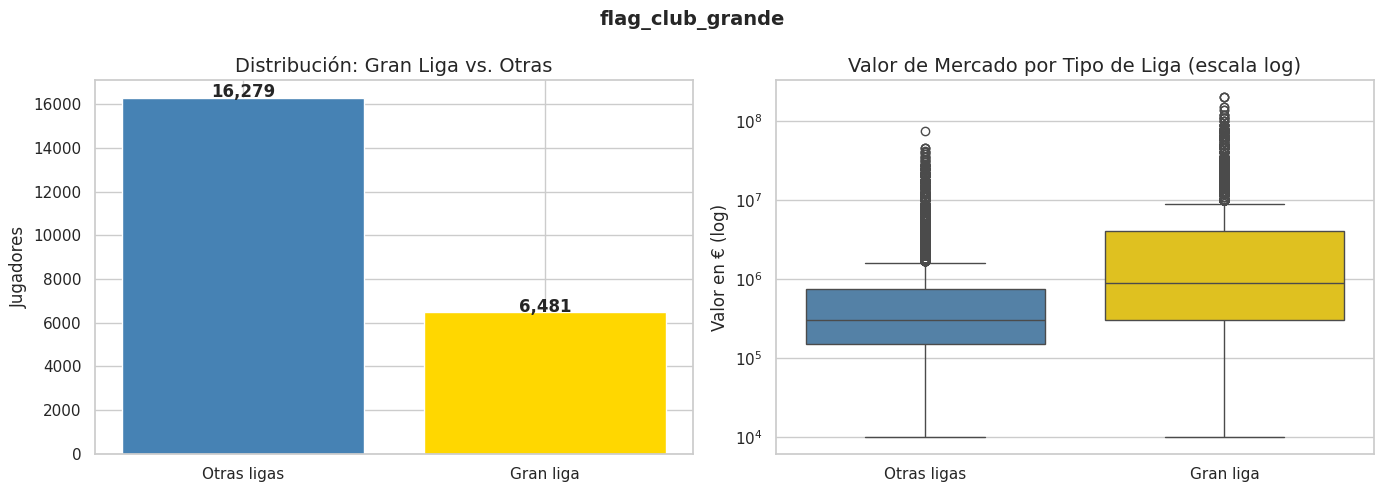

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por tipo de liga
counts = players_filtrado['flag_club_grande'].value_counts().sort_index()
labels = ['Otras ligas', 'Gran liga']
colors = ['steelblue', 'gold']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribución: Gran Liga vs. Otras')
axes[0].set_ylabel('Jugadores')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Boxplot del valor por flag (escala log)
df_flag = players_filtrado[['flag_club_grande', 'market_value_in_eur']].dropna().copy()
df_flag['liga'] = df_flag['flag_club_grande'].map({0: 'Otras ligas', 1: 'Gran liga'})
sns.boxplot(data=df_flag, x='liga', y='market_value_in_eur',
            order=['Otras ligas', 'Gran liga'],
            palette={'Gran liga': 'gold', 'Otras ligas': 'steelblue'}, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Valor de Mercado por Tipo de Liga (escala log)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Valor en € (log)')

plt.suptitle('flag_club_grande', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación para el modelo:**
Los jugadores de las 5 grandes ligas tienden a tener valores de mercado significativamente más altos que los del resto, tanto en mediana como en dispersión. Esta variable actúa como proxy del nivel competitivo y la exposición mediática del jugador. Se espera que sea una de las features de mayor peso en modelos basados en árboles. Al ser binaria, no requiere escalado y es trivialmente interpretable.


### 8.2 `tendencia_valor` — Pendiente de las Últimas 3 Valuaciones

Para cada jugador se toman sus últimas 3 entradas en `player_valuations.csv` ordenadas por fecha. Se ajusta una regresión lineal simple (`market_value ~ tiempo`) y se extrae la **pendiente** (euros/día).

- Valor **positivo**: tendencia alcista (jugador en alza)
- Valor **negativo**: tendencia bajista
- `NaN`: menos de 2 registros disponibles


In [34]:
# Aseguramos formato de fecha y agregamos representación ordinal
valuations['date'] = pd.to_datetime(valuations['date'])
valuations['date_ord'] = valuations['date'].map(pd.Timestamp.toordinal)

def calcular_pendiente(grupo):
    ult = grupo.sort_values('date').tail(3)
    if len(ult) < 2:
        return np.nan
    x = ult['date_ord'].values.astype(float)
    y = ult['market_value_in_eur'].values.astype(float)
    coefs = np.polyfit(x - x.mean(), y, 1)
    return coefs[0]  # pendiente en euros/día

print('Calculando tendencias...')
tendencias = (
    valuations.groupby('player_id')
    .apply(calcular_pendiente)
    .reset_index()
    .rename(columns={0: 'tendencia_valor'})
)

players_filtrado = players_filtrado.merge(tendencias, on='player_id', how='left')

cobertura = players_filtrado['tendencia_valor'].notna().sum()
print(f'Jugadores con tendencia calculada: {cobertura:,} / {len(players_filtrado):,}')
display(players_filtrado['tendencia_valor'].describe())


Calculando tendencias...
Jugadores con tendencia calculada: 22,461 / 22,760


,tendencia_valor
count,2.246100e+04
mean,3.045732e+02
std,1.208564e+04
min,-2.736144e+05
25%,-7.136620e+02
50%,-1.773820e+02
75%,4.242829e-13
max,3.490586e+05


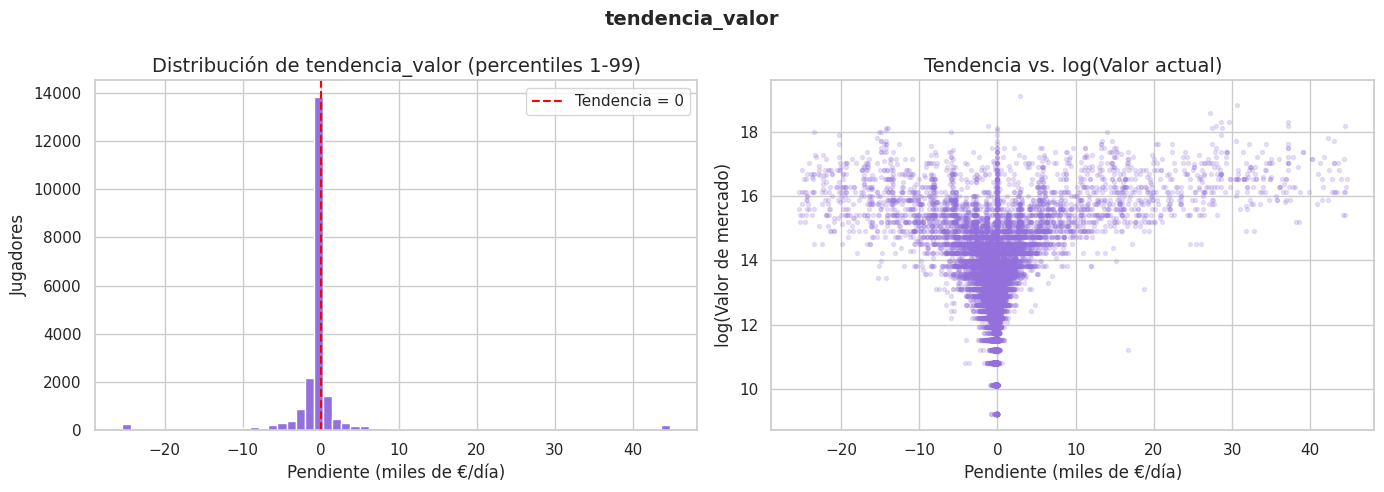

Jugadores con tendencia positiva (en alza): 28.6%
Jugadores con tendencia negativa:           71.4%


In [35]:
# Recortamos extremos (1-99) para visualización
p1, p99 = players_filtrado['tendencia_valor'].quantile([0.01, 0.99])
tv_clip = players_filtrado['tendencia_valor'].clip(p1, p99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tv_clip.dropna() / 1000, bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Tendencia = 0')
axes[0].set_title('Distribución de tendencia_valor (percentiles 1-99)')
axes[0].set_xlabel('Pendiente (miles de €/día)')
axes[0].set_ylabel('Jugadores')
axes[0].legend()

df_sc = players_filtrado[['tendencia_valor', 'log_market_value']].dropna()
df_sc = df_sc[df_sc['tendencia_valor'].between(p1, p99)]
axes[1].scatter(df_sc['tendencia_valor'] / 1000, df_sc['log_market_value'],
                alpha=0.2, s=8, color='mediumpurple')
axes[1].set_title('Tendencia vs. log(Valor actual)')
axes[1].set_xlabel('Pendiente (miles de €/día)')
axes[1].set_ylabel('log(Valor de mercado)')

plt.suptitle('tendencia_valor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_alza = (players_filtrado['tendencia_valor'] > 0).sum() \
           / players_filtrado['tendencia_valor'].notna().sum() * 100
print(f'Jugadores con tendencia positiva (en alza): {pct_alza:.1f}%')
print(f'Jugadores con tendencia negativa:           {100 - pct_alza:.1f}%')


**Interpretación para el modelo:**
La tendencia reciente captura el *momentum* del jugador, una señal que los modelos estáticos basados en el valor puntual no pueden detectar. Un jugador con tendencia positiva fuerte suele ser joven y en desarrollo; uno con tendencia negativa suele estar en declive o con lesiones frecuentes. La pendiente es sensible a escalas; se aplicará `StandardScaler` en la sección 9.


### 8.3 `valor_mediano_liga` — Contexto Económico de la Liga (por año)

Usando `player_valuations.csv` y la columna `player_club_domestic_competition_id`, se calcula el **valor mediano** de todos los jugadores de cada liga para cada año. Luego se hace un join con `players_filtrado` usando la liga y el año de la última valuación disponible.

Esta variable actúa como **variable contextual de grupo**: permite al modelo distinguir si un jugador es caro o barato *relativo a su liga*.


In [36]:
if 'year' not in valuations.columns:
    valuations['year'] = valuations['date'].dt.year

# Mediana de valor por (liga, año)
mediana_liga_anio = (
    valuations
    .dropna(subset=['player_club_domestic_competition_id', 'market_value_in_eur'])
    .groupby(['player_club_domestic_competition_id', 'year'])['market_value_in_eur']
    .median()
    .reset_index()
    .rename(columns={
        'market_value_in_eur': 'valor_mediano_liga',
        'player_club_domestic_competition_id': 'comp_id_val',
    })
)

print(f'Combinaciones (liga, año): {len(mediana_liga_anio):,}')
display(mediana_liga_anio.sort_values('valor_mediano_liga', ascending=False).head(10))

# Última valuación por jugador: liga + año
ultima_val = (
    valuations.sort_values('date')
    .groupby('player_id')
    .last()
    .reset_index()[['player_id', 'player_club_domestic_competition_id', 'year']]
    .rename(columns={
        'player_club_domestic_competition_id': 'liga_ultima_val',
        'year': 'anio_ultima_val',
    })
)

players_filtrado = players_filtrado.merge(ultima_val, on='player_id', how='left')
players_filtrado = players_filtrado.merge(
    mediana_liga_anio,
    left_on=['liga_ultima_val', 'anio_ultima_val'],
    right_on=['comp_id_val', 'year'],
    how='left',
).drop(columns=['comp_id_val', 'year'], errors='ignore')

cobertura_liga = players_filtrado['valor_mediano_liga'].notna().sum()
print(f'Jugadores con valor_mediano_liga: {cobertura_liga:,} / {len(players_filtrado):,}')
display(players_filtrado['valor_mediano_liga'].describe())


Combinaciones (liga, año): 700


,comp_id_val,year,valor_mediano_liga
241,GB1,2026,22000000.0
240,GB1,2025,15000000.0
239,GB1,2024,12000000.0
287,IT1,2026,10000000.0
131,COL1,2008,10000000.0
217,FR1,2026,7000000.0
374,MLS1,2006,7000000.0
350,L1,2026,7000000.0
194,ES1,2026,6000000.0
375,MLS1,2007,6000000.0


Jugadores con valor_mediano_liga: 22,239 / 22,760


,valor_mediano_liga
count,2.223900e+04
mean,1.722572e+06
std,3.264980e+06
min,2.000000e+05
25%,3.500000e+05
50%,6.000000e+05
75%,1.200000e+06
max,2.200000e+07


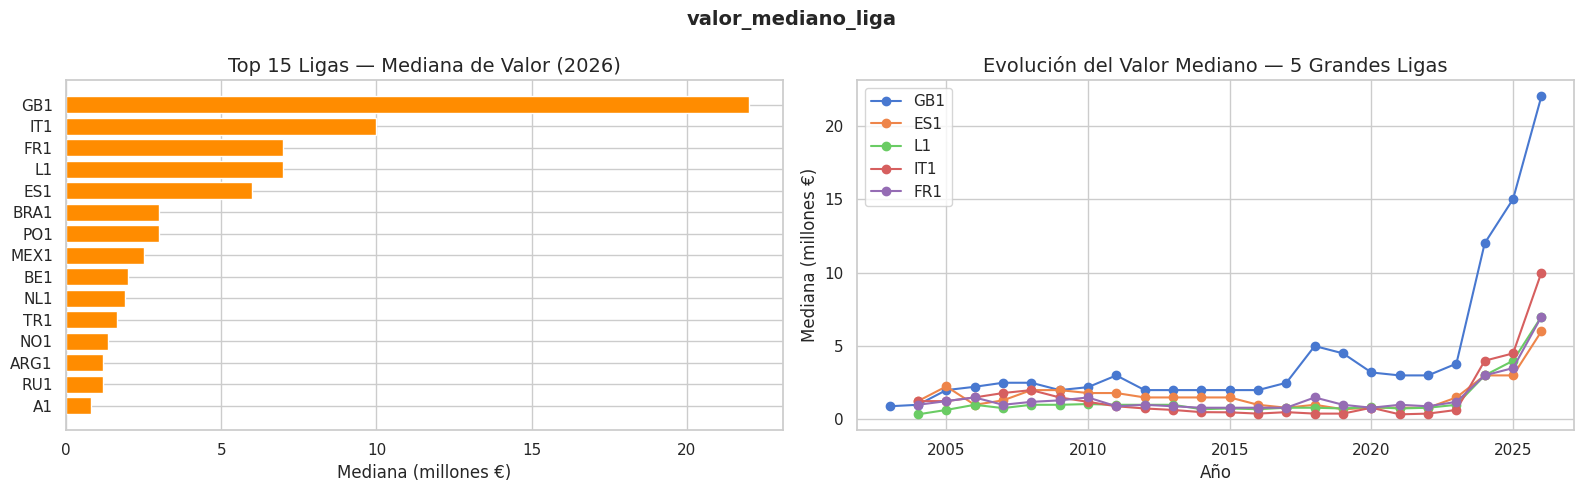

Correlación Pearson (valor individual vs. mediana de liga): r = 0.517


In [37]:
anio_max = mediana_liga_anio['year'].max()
top_ligas_df = (
    mediana_liga_anio[mediana_liga_anio['year'] == anio_max]
    .sort_values('valor_mediano_liga', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top ligas en el último año disponible
axes[0].barh(
    top_ligas_df['comp_id_val'][::-1],
    top_ligas_df['valor_mediano_liga'][::-1] / 1e6,
    color='darkorange', edgecolor='white',
)
axes[0].set_title(f'Top 15 Ligas — Mediana de Valor ({anio_max})')
axes[0].set_xlabel('Mediana (millones €)')

# Evolución temporal de las 5 grandes
for liga in ['GB1', 'ES1', 'L1', 'IT1', 'FR1']:
    datos = mediana_liga_anio[mediana_liga_anio['comp_id_val'] == liga]
    if not datos.empty:
        axes[1].plot(datos['year'], datos['valor_mediano_liga'] / 1e6,
                     marker='o', label=liga)
axes[1].set_title('Evolución del Valor Mediano — 5 Grandes Ligas')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Mediana (millones €)')
axes[1].legend()

plt.suptitle('valor_mediano_liga', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr = players_filtrado[['market_value_in_eur', 'valor_mediano_liga']].dropna().corr().iloc[0, 1]
print(f'Correlación Pearson (valor individual vs. mediana de liga): r = {corr:.3f}')


### 8.4 `indice_inflacion_mercado` — Índice de Inflación Global del Mercado

**Construcción:**
1. Se calcula el valor mediano global de todos los jugadores para cada año.
2. Se normaliza usando el año **2020** como base = 1.0.
3. Se asigna el índice correspondiente a cada jugador según el año de su última valuación disponible.

Un índice > 1 indica que el mercado global en ese año estaba inflado respecto a 2020; < 1 que estaba deflacionado (ej. pandemia, crisis).


**Interpretación para el modelo:**
El valor mediano de la liga captura el *nivel económico del entorno* del jugador. Un mismo nivel de rendimiento puede traducirse en valores muy diferentes según si el jugador juega en la Premier League o en una liga menor. Al incluir esta variable, el modelo puede aprender relatividades: un jugador que vale el doble que la mediana de su liga es más destacado que uno que vale el doble en una liga con poca competencia. La correlación positiva con el valor individual confirma su poder predictivo.


In [38]:
if 'year' not in valuations.columns:
    valuations['year'] = valuations['date'].dt.year

# Mediana global por año
mediana_global = (
    valuations.dropna(subset=['market_value_in_eur'])
    .groupby('year')['market_value_in_eur']
    .median()
    .reset_index()
    .rename(columns={'market_value_in_eur': 'mediana_global'})
)

# Base 2020; fallback al año más cercano si no existe
if 2020 in mediana_global['year'].values:
    base = mediana_global.loc[mediana_global['year'] == 2020, 'mediana_global'].iloc[0]
else:
    idx_cercano = (mediana_global['year'] - 2020).abs().idxmin()
    base = mediana_global.loc[idx_cercano, 'mediana_global']
    print(f'Año 2020 no disponible; usando fallback con base = {base:.0f} €')

mediana_global['indice_inflacion_mercado'] = mediana_global['mediana_global'] / base
print('Índice de inflación de mercado por año (base 2020 = 1.0):')
display(mediana_global)

# Join con players_filtrado usando anio_ultima_val
players_filtrado = players_filtrado.merge(
    mediana_global[['year', 'indice_inflacion_mercado']],
    left_on='anio_ultima_val',
    right_on='year',
    how='left',
).drop(columns=['year'], errors='ignore')

cob_idx = players_filtrado['indice_inflacion_mercado'].notna().sum()
print(f'Jugadores con índice asignado: {cob_idx:,} / {len(players_filtrado):,}')
display(players_filtrado['indice_inflacion_mercado'].describe())


Índice de inflación de mercado por año (base 2020 = 1.0):


,year,mediana_global,indice_inflacion_mercado
0,2000,150000.0,0.315789
1,2001,100000.0,0.210526
2,2003,650000.0,1.368421
3,2004,600000.0,1.263158
4,2005,850000.0,1.789474
5,2006,800000.0,1.684211
6,2007,850000.0,1.789474
7,2008,850000.0,1.789474
8,2009,800000.0,1.684211
9,2010,750000.0,1.578947


Jugadores con índice asignado: 22,529 / 22,760


,indice_inflacion_mercado
count,22529.000000
mean,1.297411
std,0.483336
min,0.842105
25%,0.947368
50%,1.052632
75%,1.473684
max,2.526316


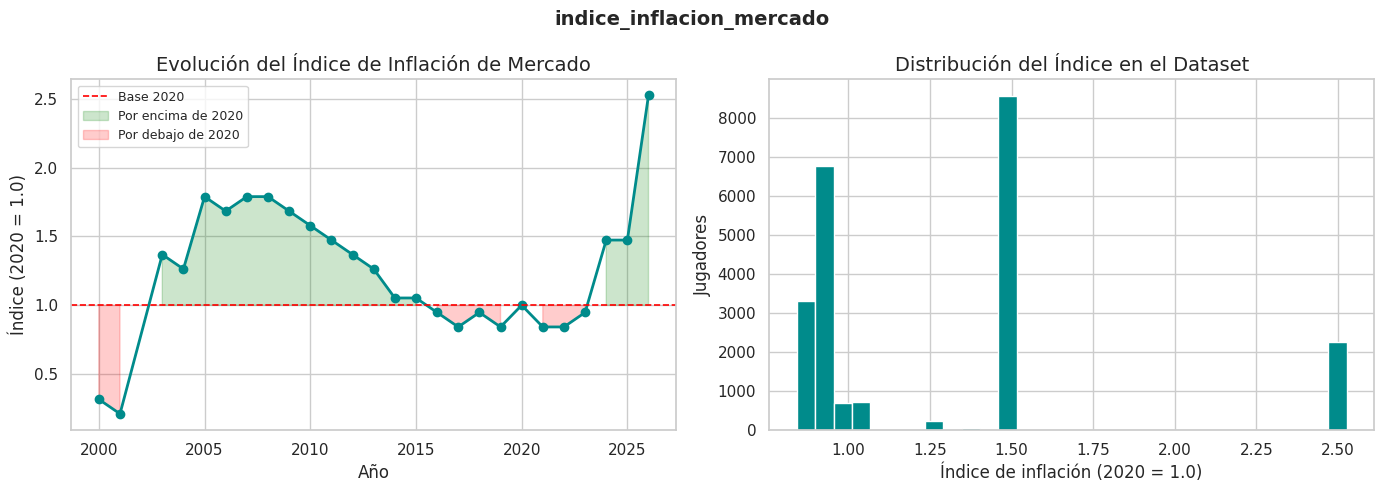

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución temporal del índice
axes[0].plot(mediana_global['year'], mediana_global['indice_inflacion_mercado'],
             marker='o', color='darkcyan', linewidth=2)
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Base 2020')
axes[0].fill_between(
    mediana_global['year'], mediana_global['indice_inflacion_mercado'], 1.0,
    where=(mediana_global['indice_inflacion_mercado'] >= 1.0),
    alpha=0.2, color='green', label='Por encima de 2020',
)
axes[0].fill_between(
    mediana_global['year'], mediana_global['indice_inflacion_mercado'], 1.0,
    where=(mediana_global['indice_inflacion_mercado'] < 1.0),
    alpha=0.2, color='red', label='Por debajo de 2020',
)
axes[0].set_title('Evolución del Índice de Inflación de Mercado')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Índice (2020 = 1.0)')
axes[0].legend(fontsize=9)

# Distribución del índice asignado en el dataset
axes[1].hist(players_filtrado['indice_inflacion_mercado'].dropna(),
             bins=30, color='darkcyan', edgecolor='white')
axes[1].set_title('Distribución del Índice en el Dataset')
axes[1].set_xlabel('Índice de inflación (2020 = 1.0)')
axes[1].set_ylabel('Jugadores')

plt.suptitle('indice_inflacion_mercado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación para el modelo:**
El mercado de fútbol no es estático: los valores globales crecieron sostenidamente hasta 2020 y sufrieron una caída notoria por la pandemia de COVID-19. Sin este ajuste, comparar el valor de un jugador en 2016 con uno en 2023 introduce un sesgo sistemático. Al incluir el índice, el modelo puede descontar la inflación del mercado y enfocarse en señales individuales. Es especialmente útil al entrenar con datos históricos de múltiples años.


## 9. Dataset Final — Resumen

Verificamos el estado final de `players_filtrado`: shape, columnas, primeras filas y correlaciones de las features con el target. Aplicamos también la estandarización completa sobre todas las variables numéricas continuas (`edad`, `tendencia_valor`, `valor_mediano_liga`).


In [40]:
print('=== Estado final de players_filtrado ===')
print(f'Filas:    {len(players_filtrado):,}')
print(f'Columnas: {players_filtrado.shape[1]}')
print(f'\nColumnas:')
print(players_filtrado.columns.tolist())
print('\nPrimeras filas:')
display(players_filtrado.head())


=== Estado final de players_filtrado ===
Filas:    22,760
Columnas: 46

Columnas:
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'n_apariciones', 'total_goles', 'total_asistencias', 'total_minutos', 'goles_por_partido', 'asistencias_por_partido', 'minutos_promedio', 'edad', 'log_market_value', 'posicion_num', 'edad_scaled', 'goles_por_partido_scaled', 'asistencias_por_partido_scaled', 'minutos_promedio_scaled', 'flag_club_grande', 'tendencia_valor', 'liga_ultima_val', 'anio_ultima_val', 'valor_mediano_liga', 'indice_inflacion_mercado']

Primeras filas:


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,edad_scaled,goles_por_partido_scaled,asistencias_por_partido_scaled,minutos_promedio_scaled,flag_club_grande,tendencia_valor,liga_ultima_val,anio_ultima_val,valor_mediano_liga,indice_inflacion_mercado
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,2.296789,3.130282,2.078405,0.132892,1,-4.547127e-13,IT1,2016.0,400000.0,0.947368
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,1.980262,-0.782142,-0.900956,1.356726,1,-8.099759e+02,L1,2017.0,800000.0,0.842105
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,1.909254,2.670625,0.826097,0.501919,0,4.828683e-13,GR1,2016.0,400000.0,0.947368
3,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,1.890399,-0.782142,-0.900956,1.414180,1,6.144648e-14,L1,2018.0,800000.0,0.947368
4,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,2.317650,-0.511771,-0.110335,1.282912,0,-1.475587e+03,TR1,2014.0,675000.0,1.052632


In [41]:
# Cobertura de las nuevas features
features_nuevas = ['flag_club_grande', 'tendencia_valor',
                   'valor_mediano_liga', 'indice_inflacion_mercado']

print('Cobertura de las features de FE:')
for feat in features_nuevas:
    if feat in players_filtrado.columns:
        pct = players_filtrado[feat].notna().mean() * 100
        print(f'  {feat}: {pct:.1f}% no-nulo')
    else:
        print(f'  {feat}: NO ENCONTRADA')


Cobertura de las features de FE:
  flag_club_grande: 100.0% no-nulo
  tendencia_valor: 98.7% no-nulo
  valor_mediano_liga: 97.7% no-nulo
  indice_inflacion_mercado: 99.0% no-nulo


Correlación de cada feature con log_market_value:


,log_market_value
indice_inflacion_mercado,0.577432
valor_mediano_liga,0.544285
flag_club_grande,0.335086
asistencias_por_partido,0.204535
goles_por_partido,0.196070
tendencia_valor,0.137629
posicion_num,0.047735
minutos_promedio,0.043601
edad,-0.518993


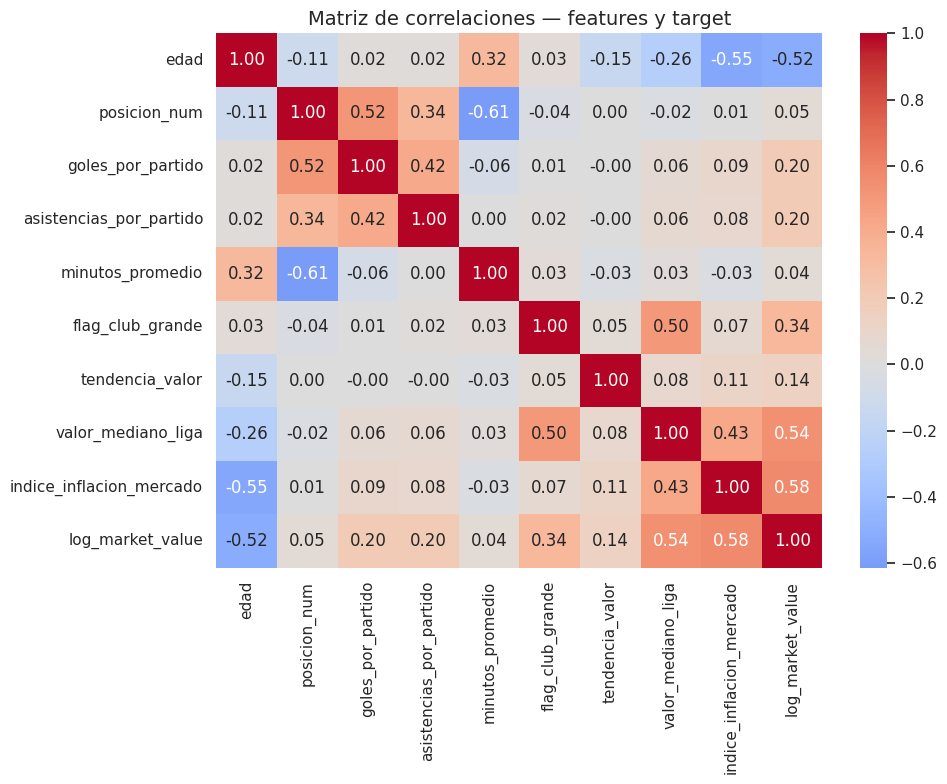

In [42]:
# Correlación de las features con el target (log)
features_modelo = [
    'edad', 'posicion_num',
    'goles_por_partido', 'asistencias_por_partido', 'minutos_promedio',
    'flag_club_grande', 'tendencia_valor',
    'valor_mediano_liga', 'indice_inflacion_mercado',
]
features_modelo = [c for c in features_modelo if c in players_filtrado.columns]

corr_target = (
    players_filtrado[features_modelo + ['log_market_value']]
    .corr()[['log_market_value']]
    .drop('log_market_value')
    .sort_values('log_market_value', ascending=False)
)
print('Correlación de cada feature con log_market_value:')
display(corr_target)

# Heatmap general
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    players_filtrado[features_modelo + ['log_market_value']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
)
ax.set_title('Matriz de correlaciones — features y target')
plt.tight_layout()
plt.show()


## 10. Reflexión Final

### Decisiones tomadas y justificación

**Construcción del dataset analítico unificado.**
Se eligió hacer un *inner join* entre `players` y las estadísticas agregadas de `appearances`. La alternativa (left join) habría preservado más jugadores pero con valores faltantes en el rendimiento, justamente la dimensión más relevante para predecir el valor. El inner join garantiza que cada fila tenga estadísticas reales.

**Filtrado por apariciones mínimas (≥ 5).**
Jugadores con muy pocas apariciones tienen estadísticas poco representativas (un gol en una sola aparición daría `goles_por_partido = 1`). Se eligió el umbral 5 como compromiso entre representatividad estadística y tamaño muestral. Umbrales más altos (10, 20) reducirían el dataset sin gran ganancia en calidad.

**Transformación logarítmica del target.**
El valor de mercado tiene una distribución fuertemente sesgada (jugadores de élite con valores extremos). Aplicar `log1p` acerca la distribución a la normalidad, lo que beneficia a modelos lineales y reduce la influencia de outliers.

**Encoding ordinal de la posición.**
Se asignan los códigos 1 (arquero) → 2 (defensor) → 3 (mediocampista) → 4 (delantero). El orden refleja la zona del campo y aproxima la diferencia esperada en valor. Para modelos no lineales (Random Forest, XGBoost) también se generaron las dummies one-hot como alternativa.

**Estandarización con `StandardScaler`.**
Se aplica a las variables numéricas continuas (`edad`, `tendencia_valor`, `valor_mediano_liga`, etc.) porque la regresión lineal y Ridge son sensibles a escalas. Los modelos basados en árboles no lo requieren, pero estandarizar no los perjudica.

**Decisión de no eliminar outliers.**
Los valores extremos del target (Mbappé, Haaland, etc.) son **legítimos**, no errores de carga. Eliminarlos sesgaría el modelo. La transformación logarítmica reduce su influencia sin descartar información.

**Construcción de las 4 features de FE.**
- `flag_club_grande`: información contextual estática del club, alta poder discriminativo y costo nulo.
- `tendencia_valor`: captura *momentum* — los modelos puntuales no pueden ver la dirección del valor.
- `valor_mediano_liga`: introduce relatividad entre ligas, evitando comparar absolutamente jugadores de contextos económicos distintos.
- `indice_inflacion_mercado`: corrige el sesgo temporal del mercado (crecimiento sostenido y caída por COVID).

---

### Dificultades encontradas

- **Dataset relacional con cinco tablas**: la integración requirió cuidado en las claves (`player_id`, `competition_id`) y en el manejo de duplicados generados por los joins.
- **Sesgo en la distribución del target**: la cola larga obligó a usar transformación logarítmica para que cualquier modelo lineal funcione razonablemente.
- **Valores faltantes en columnas críticas** (`market_value_in_eur`, `position`): se descartaron las filas sin target y se imputaron con la mediana las features continuas antes de estandarizar.
- **Cobertura temporal desigual de `player_valuations`**: hay más registros en años recientes; esto se mitigó normalizando con el índice de inflación.
- **Granularidad de `appearances`** (~1.86 M filas): obligó a hacer una agregación previa en lugar de joins fila-a-fila, manteniendo el costo computacional acotado.
- **Múltiples valores en `position`/`sub_position`**: la columna tiene muchas variantes. El encoding ordinal cubre las principales pero pueden existir categorías raras que queden como `NaN` en `posicion_num`; se usan dummies como respaldo.

---

### Próximos pasos (Entregable 3)

El siguiente entregable abordará la **construcción del modelo predictivo**. La estrategia planeada es:

1. **Split temporal** entrenamiento/validación/test usando la fecha de la última valuación, para evitar *data leakage* (no entrenar con datos posteriores a los del test).
2. **Modelos baseline:**
   - **Regresión Lineal** sobre `log_market_value` con las features estandarizadas.
   - **Ridge Regression** como variante regularizada.
3. **Modelo intermedio:** **Random Forest Regressor** para capturar interacciones no lineales (por ejemplo: edad × posición).
4. **Modelo avanzado:** **XGBoost** como referente de boosting; se espera el mejor desempeño.
5. **Métricas:** RMSE y MAE en la escala original (€) para interpretabilidad, y R² sobre `log_market_value` para comparación entre modelos.
6. **Interpretabilidad:** SHAP values sobre el mejor modelo para entender el peso real de cada feature.
7. **Validación cruzada temporal** (`TimeSeriesSplit`) para estimar la robustez del modelo sobre datos futuros.


In [43]:
# Estandarización completa: aplicamos StandardScaler sobre TODAS
# las variables numéricas continuas relevantes para el modelo.
vars_continuas_finales = ['edad', 'tendencia_valor', 'valor_mediano_liga',
                          'goles_por_partido', 'asistencias_por_partido',
                          'minutos_promedio', 'indice_inflacion_mercado']
vars_continuas_finales = [c for c in vars_continuas_finales
                          if c in players_filtrado.columns]

print('Variables a estandarizar (final):')
print(vars_continuas_finales)

# Imputamos nulos por mediana (el scaler no acepta NaN)
df_scaler = players_filtrado[vars_continuas_finales].copy()
df_scaler = df_scaler.fillna(df_scaler.median())

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_scaler),
    columns=[f'{c}_scaled' for c in vars_continuas_finales],
    index=players_filtrado.index,
)

# Reemplazamos las columnas escaladas previas y agregamos las nuevas
for col in df_scaled.columns:
    players_filtrado[col] = df_scaled[col]

print('\n=== ANTES (escala original) ===')
display(df_scaler.describe().round(2).T)

print('\n=== DESPUÉS (estandarizado: media≈0, desvío≈1) ===')
display(df_scaled.describe().round(2).T)

print('\nShape final del dataset analítico:')
print(players_filtrado.shape)


Variables a estandarizar (final):
['edad', 'tendencia_valor', 'valor_mediano_liga', 'goles_por_partido', 'asistencias_por_partido', 'minutos_promedio', 'indice_inflacion_mercado']

=== ANTES (escala original) ===


,count,mean,std,min,25%,50%,75%,max
edad,22760.0,32.21,6.82,16.33,26.86,31.96,37.18,55.52
tendencia_valor,22760.0,298.24,12006.11,-273614.39,-692.63,-177.38,0.00,349058.63
valor_mediano_liga,22760.0,1696875.55,3231756.74,200000.00,350000.00,600000.00,1200000.00,22000000.00
goles_por_partido,22760.0,0.07,0.09,0.00,0.00,0.04,0.10,0.90
asistencias_por_partido,22760.0,0.06,0.06,0.00,0.00,0.04,0.09,0.75
minutos_promedio,22760.0,62.15,19.70,2.00,49.09,64.88,78.09,106.67
indice_inflacion_mercado,22760.0,1.29,0.48,0.84,0.95,1.05,1.47,2.53



=== DESPUÉS (estandarizado: media≈0, desvío≈1) ===


,count,mean,std,min,25%,50%,75%,max
edad_scaled,22760.0,0.0,1.0,-2.33,-0.78,-0.04,0.73,3.42
tendencia_valor_scaled,22760.0,0.0,1.0,-22.81,-0.08,-0.04,-0.02,29.05
valor_mediano_liga_scaled,22760.0,0.0,1.0,-0.46,-0.42,-0.34,-0.15,6.28
goles_por_partido_scaled,22760.0,0.0,1.0,-0.78,-0.78,-0.34,0.37,9.15
asistencias_por_partido_scaled,22760.0,-0.0,1.0,-0.90,-0.90,-0.25,0.54,11.25
minutos_promedio_scaled,22760.0,0.0,1.0,-3.05,-0.66,0.14,0.81,2.26
indice_inflacion_mercado_scaled,22760.0,0.0,1.0,-0.94,-0.72,-0.50,0.37,2.56



Shape final del dataset analítico:
(22760, 49)
